# Orange County Analysis

In [1]:
# Import statements
import pandas as pd

from utils import (
    load_census,
    add_standardized_race,
    census_rollup,
    discretionary_policing_analysis,
    full_policing_analysis,
    prosecution_rates_by_statute_level,
    visualize_policing,
    visualize_prosecution,
    save_policing,
    save_prosecution
)

# Display all columns
pd.set_option('display.max_columns', None)

# Import Data

In [2]:
# Load in policing data
original_policing = pd.read_csv("../data/cleaned/cleaned_orange_ripa_2019_2023.csv")

# Select only relevant columns to use
keep_cols = [
    "doj_record_id",
    "person_number",
    "agency_ori",
    "agency_name",
    "time_of_stop",
    "date_of_stop",
    "year",
    "stop_duration",
    "closest_city",
    "race_ethnicity",
    "gender",
    "age",
    "reason_for_contact",
    "traffic_violation_cjis_offense_code",
    "suspicion_cjis_offense_code",
    "suspicion",
    "action_any_search",
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory",
    "contraband_any",
    "result_of_stop_arrest",
    "search_type",
    "multi_person_stop"
]
policing = original_policing[[c for c in keep_cols if c in original_policing.columns]].copy()

# Add standardized race column to match policing and prosecution labels
policing = add_standardized_race(policing, "race_ethnicity")

# Save a copy of the full policing table for use later
all_policing = policing.copy()

<positron-console-cell-2>:2: DtypeWarning: Columns (0: time_of_stop, 1: school_code, 2: school_name, 3: ros_warning_cds, 4: ros_citation_cds, 5: ros_in_field_cite_release_cds, 6: ros_custodial_wout_warrant_cds) have mixed types. Specify dtype option on import or set low_memory=False.


In [3]:
# Load in prosecution data
prosecution = pd.read_csv("https://raw.githubusercontent.com/laurenbchu/honors-thesis/main/data/cleaned/cleaned_orange_aclu_2021_2023.csv", low_memory=False)
prosecution['filed_date'] = pd.to_datetime(prosecution["filed_date"])
prosecution['Year'] = prosecution['filed_date'].dt.year

In [4]:
# Load in census data
census = load_census("06059")

# Roll-up census data to be more coarse to match policing/prosecution race categories
census_coarse = census_rollup(census)

# Policing Analysis

In [5]:
# Analysis table of all stops, discretionary and non-discretionary reasons for contact
full_policing_analysis = full_policing_analysis(all_policing, census_coarse)
full_policing_analysis

,Year,Perceived Race,Stop Count,Search Count,Hit Count,Search Rate,Hit Rate,Population,"Stops per 1,000","Searches per 1,000"
0,2019,Asian,3115,202,81,0.064848,0.400990,699124,4.455576,0.288933
1,2019,Black/African American,1980,414,141,0.209091,0.340580,49304,40.159013,8.396885
2,2019,Hispanic/Latino,16041,3371,1231,0.210149,0.365174,1086834,14.759384,3.101670
3,2019,Other,3723,194,73,0.052109,0.376289,153072,24.321888,1.267377
4,2019,White,25537,4571,1908,0.178995,0.417414,1198655,21.304712,3.813441
5,2020,Asian,2530,270,121,0.106719,0.448148,699124,3.618814,0.386198
6,2020,Black/African American,1583,388,147,0.245104,0.378866,49304,32.106928,7.869544
7,2020,Hispanic/Latino,13756,3739,1502,0.271809,0.401712,1086834,12.656947,3.440268
8,2020,Other,2740,232,83,0.084672,0.357759,153072,17.900073,1.515627
9,2020,White,19246,3999,1788,0.207783,0.447112,1198655,16.056330,3.336239


In [6]:
# Filter for only discretionary stops
policing = policing[policing["reason_for_contact"].isin([
    "Moving violation",
    "Equipment violation",
    "Non-moving violation",
    "Suspect criminal activity"
])].copy()

# Consider only purely discretionary searches in search and hit rates

# Clean contraband_any (handles NaN, 0/1, True/False)
policing["contraband_any"] = policing["contraband_any"].fillna(0).astype(int)

# Create discretionary search indicator
policing["disc_search"] = policing["search_type"].eq("Discretionary only")

# Create hits among discretionary searches indicator
policing["disc_hit"] = policing["disc_search"] & policing["contraband_any"].eq(1)

discretionary_policing_analysis = discretionary_policing_analysis(policing, census_coarse)
discretionary_policing_analysis

,Year,Perceived Race,Stop Count,Discretionary Search Count,Discretionary Hit Count,Discretionary Search Rate,Discretionary Hit Rate,Population,"Stops per 1,000","Discretionary Searches per 1,000"
0,2019,Asian,3001,72,23,0.023992,0.319444,699124,4.292515,0.102986
1,2019,Black/African American,1785,166,46,0.092997,0.277108,49304,36.203959,3.366867
2,2019,Hispanic/Latino,14412,1474,391,0.102276,0.265265,1086834,13.260535,1.356233
3,2019,Other,3613,79,20,0.021865,0.253165,153072,23.603272,0.516097
4,2019,White,23042,1701,590,0.073822,0.346855,1198655,19.223213,1.419091
5,2020,Asian,2356,76,22,0.032258,0.289474,699124,3.369932,0.108707
6,2020,Black/African American,1381,140,43,0.101376,0.307143,49304,28.009898,2.839526
7,2020,Hispanic/Latino,11782,1509,427,0.128077,0.282969,1086834,10.840662,1.388437
8,2020,Other,2632,104,32,0.039514,0.307692,153072,17.194523,0.679419
9,2020,White,16917,1385,527,0.081870,0.380505,1198655,14.113319,1.155462


## Prosecution Rates

In [7]:
# Standardize race labels to match with policing data
prosecution = add_standardized_race(prosecution, "canonical_race")

# Create race x year x statute_level prosecution summary table
prosecution_analysis = prosecution_rates_by_statute_level(prosecution)

prosecution_analysis

,Canonical Race,Year,statute_level,Total Charges,Enhancement Rate
0,Asian,2021,Felony,1251,0.000799
1,Asian,2021,Misdemeanor,2768,0.142702
2,Asian,2022,Felony,1090,0.003670
3,Asian,2022,Misdemeanor,2289,0.174749
4,Asian,2023,Felony,876,0.001142
5,Asian,2023,Misdemeanor,1325,0.163774
6,Black/African American,2021,Felony,1689,0.008289
7,Black/African American,2021,Misdemeanor,3014,0.112143
8,Black/African American,2022,Felony,2195,0.006834
9,Black/African American,2022,Misdemeanor,2881,0.112114


# Visualizations

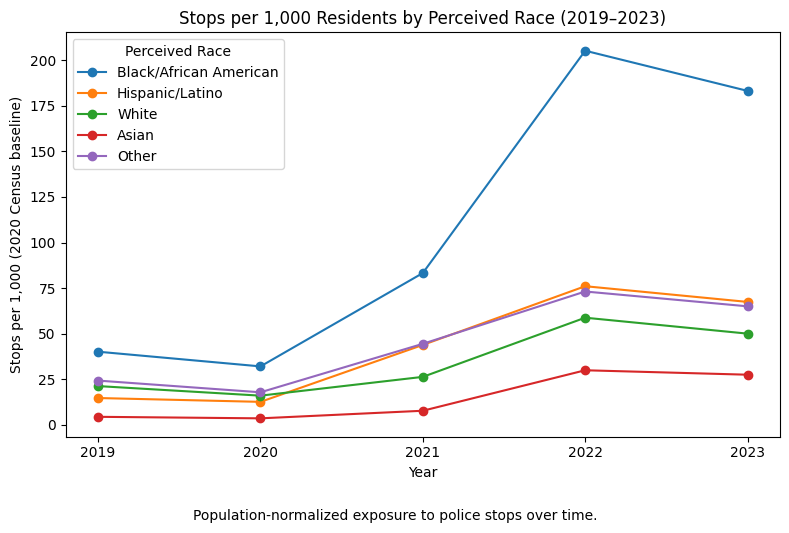

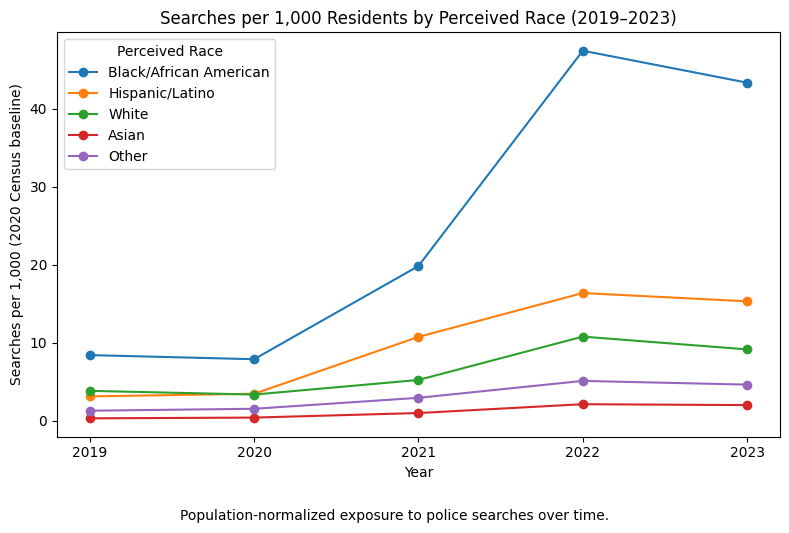

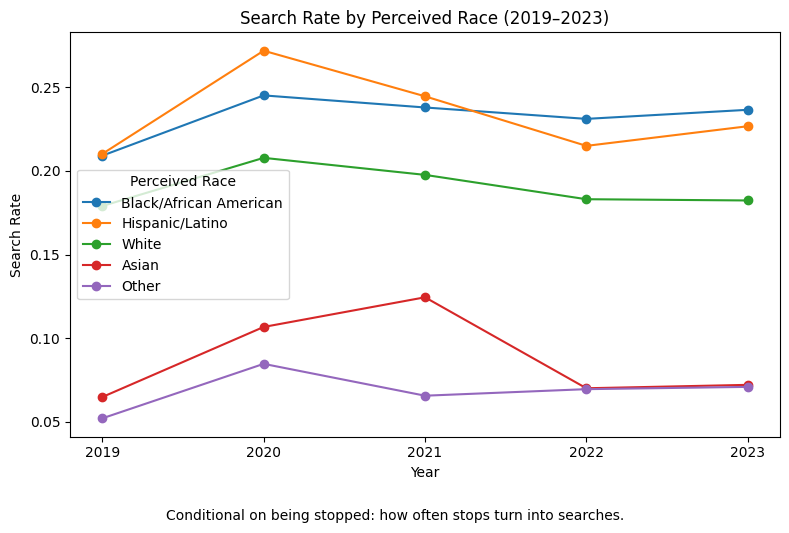

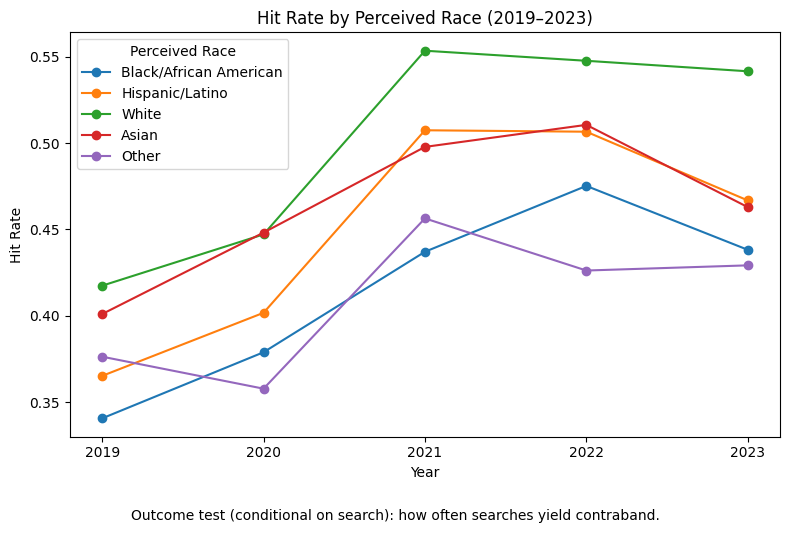

In [8]:
visualize_policing(full_policing_analysis)

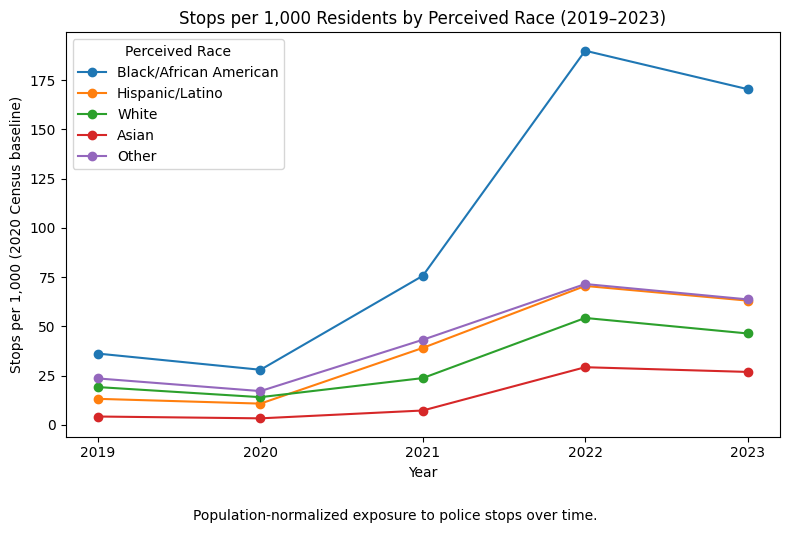

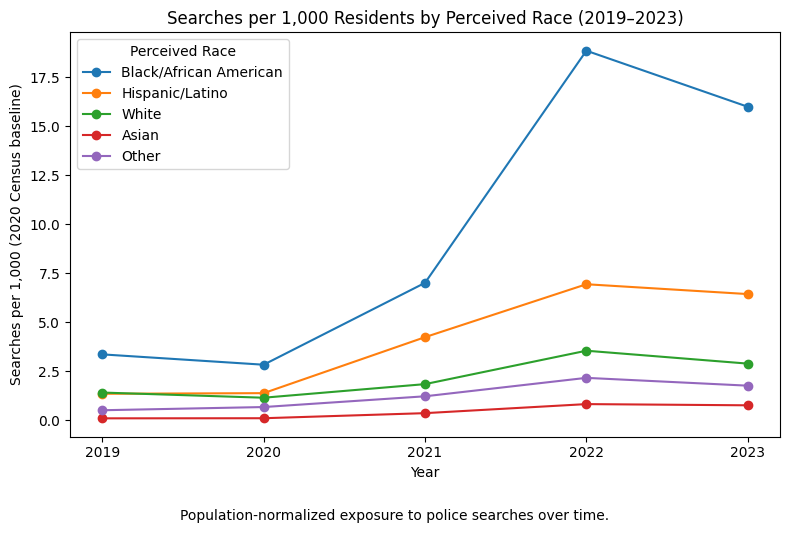

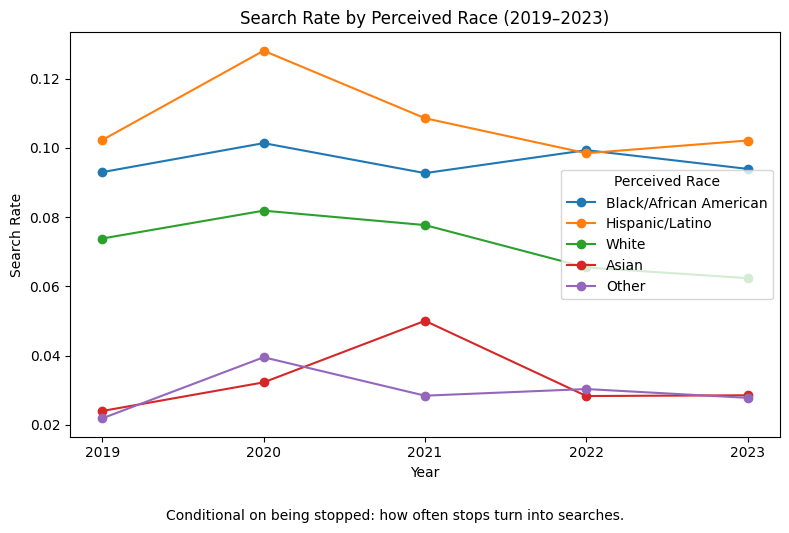

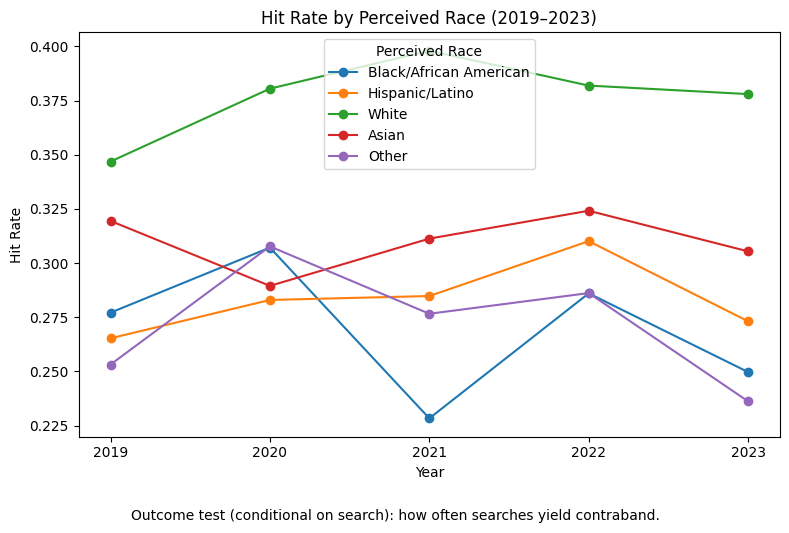

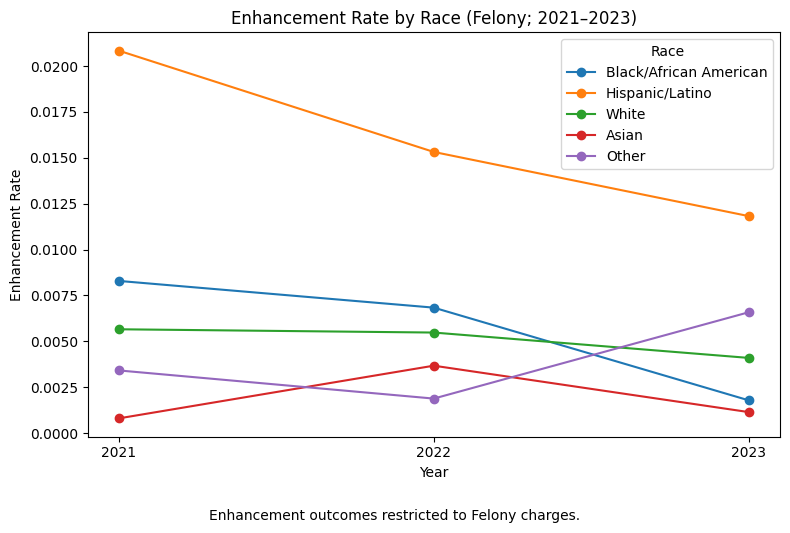

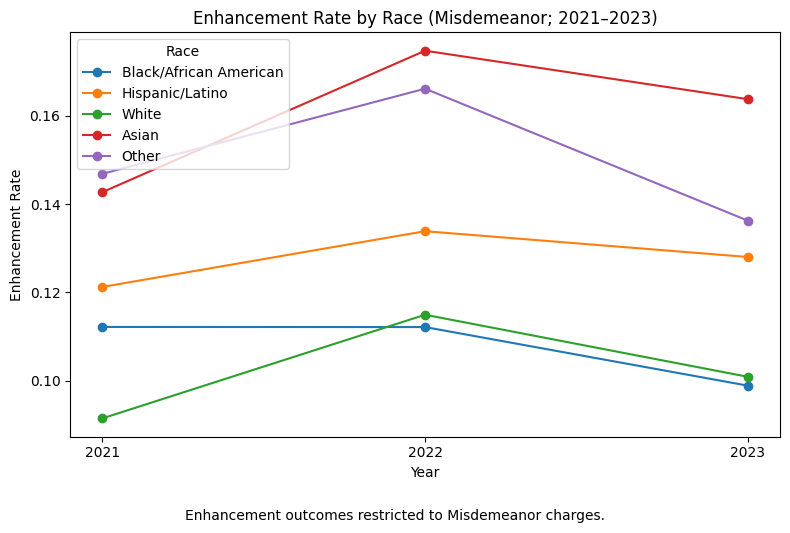

In [10]:
# Need to rename columns before calling function
disc_vis = discretionary_policing_analysis.rename(columns={
    "Discretionary Searches per 1,000": "Searches per 1,000",
    "Discretionary Search Rate": "Search Rate",
    "Discretionary Hit Rate": "Hit Rate",
    "Discretionary Search Count": "Search Count",
    "Discretionary Hit Count": "Hit Count",
})
visualize_policing(disc_vis)
visualize_prosecution(prosecution_analysis)

In [ ]:
#save_policing(policing_analysis)
#save_prosecution(prosecution_analysis)

In [ ]:
# Saves the tables
#with open("../output/policing_analysis.tex", "w") as f:
#    f.write(policing_analysis.to_latex(index=False))

#with open("../output/prosecution_analysis.tex", "w") as f:
#    f.write(prosecution_analysis.to_latex(index=False))

# Notes for Josh
1. Couldn't add in 2018 data because no Orange County data yet, only bigger counties
2. Didn't add in 2024 data because “Legislation mandated an update to the RIPA data variables starting in the 2024 reporting year” so variables became more complicated, so I couldn't just apply my normal functions for cleaning. Should I still include? Or focus time elsewhere. Include if I have time maybe? Decided against the risk-adjusted regression for 2024 because would only apply to policing and not prosecution.
3. Didn't have time to really think about visualizations

# New Visualizations
Is this even better? Still finicky with discretionary.

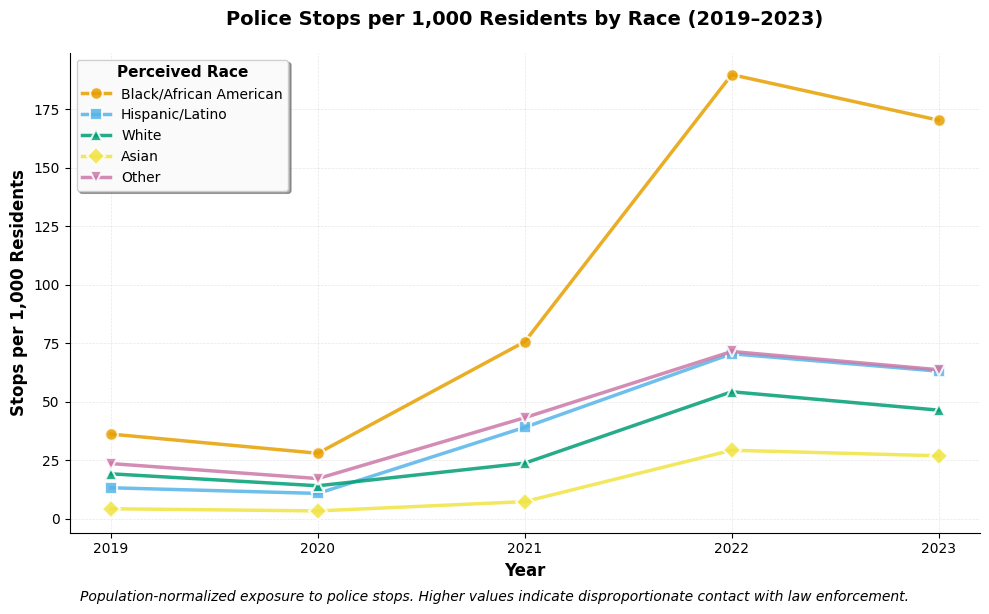

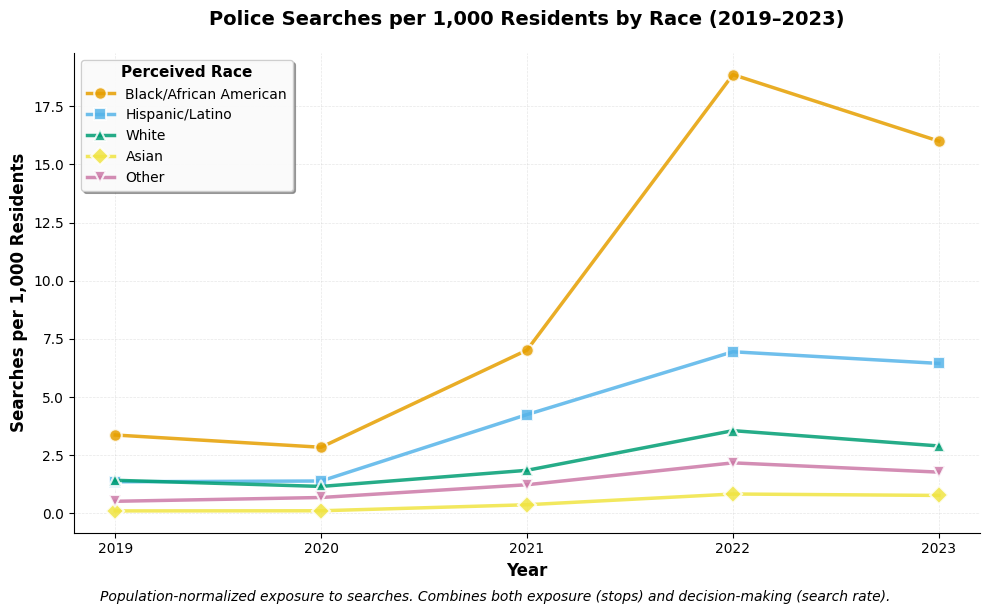

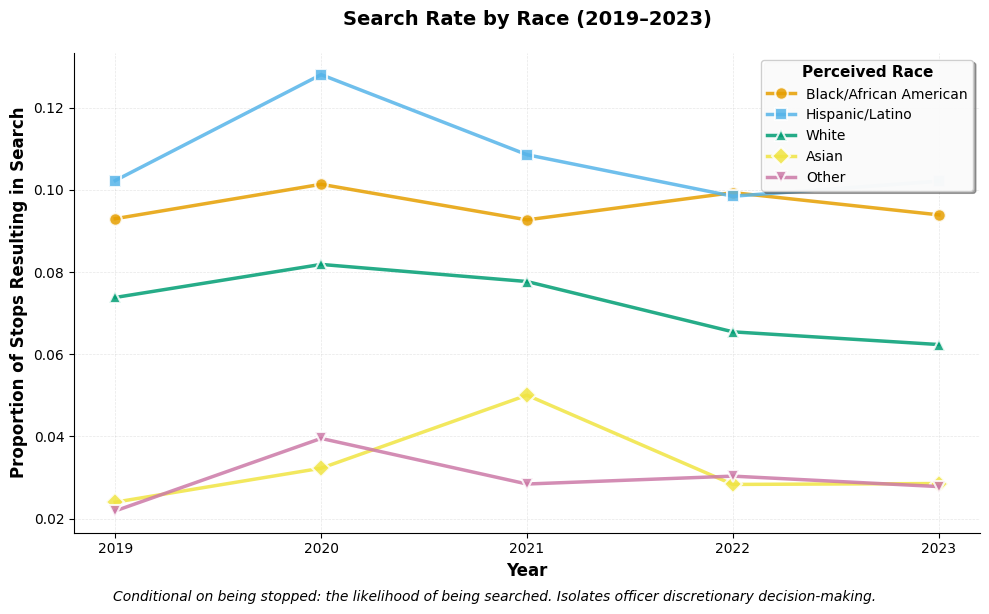

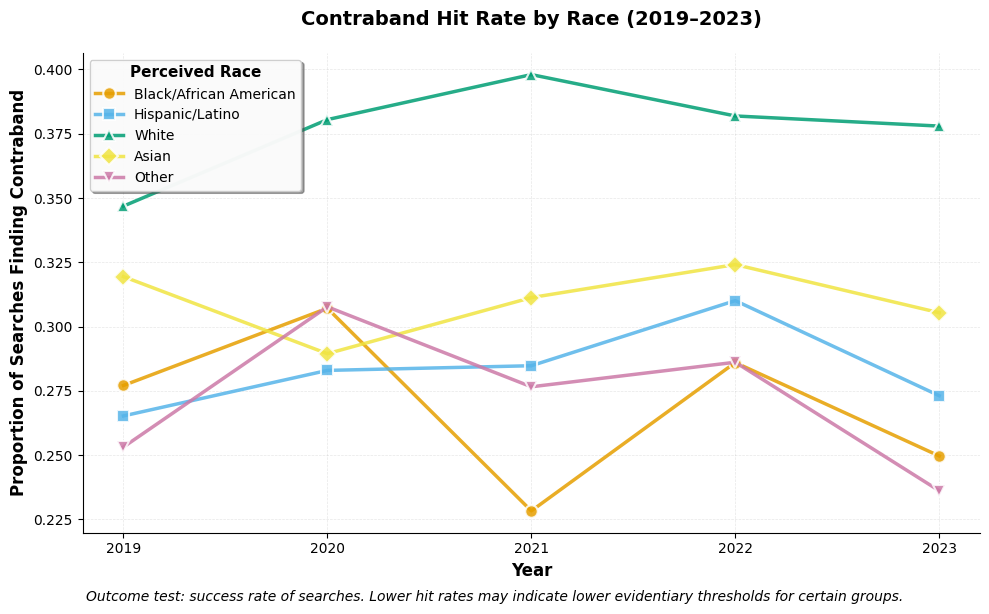

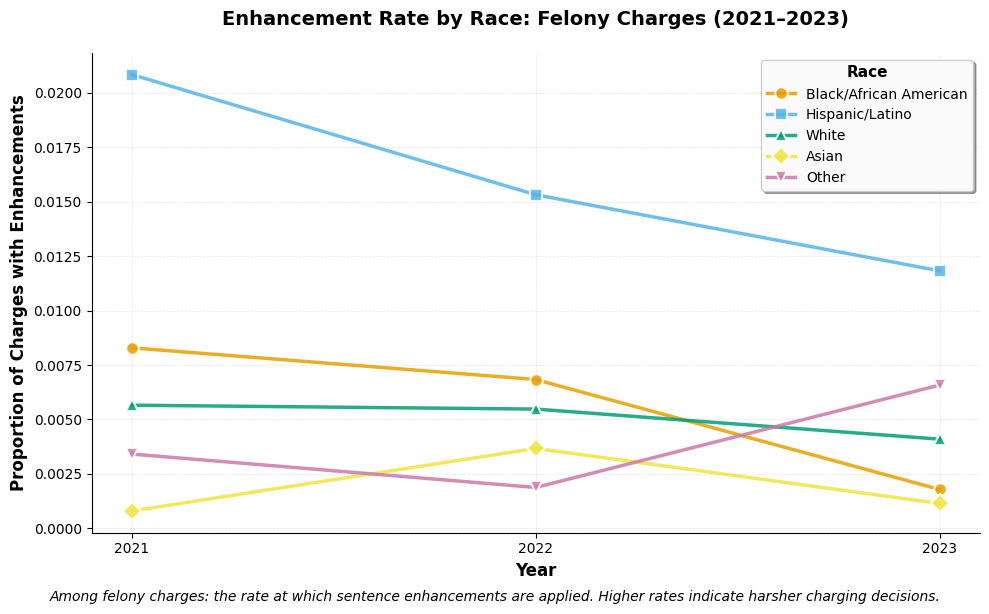

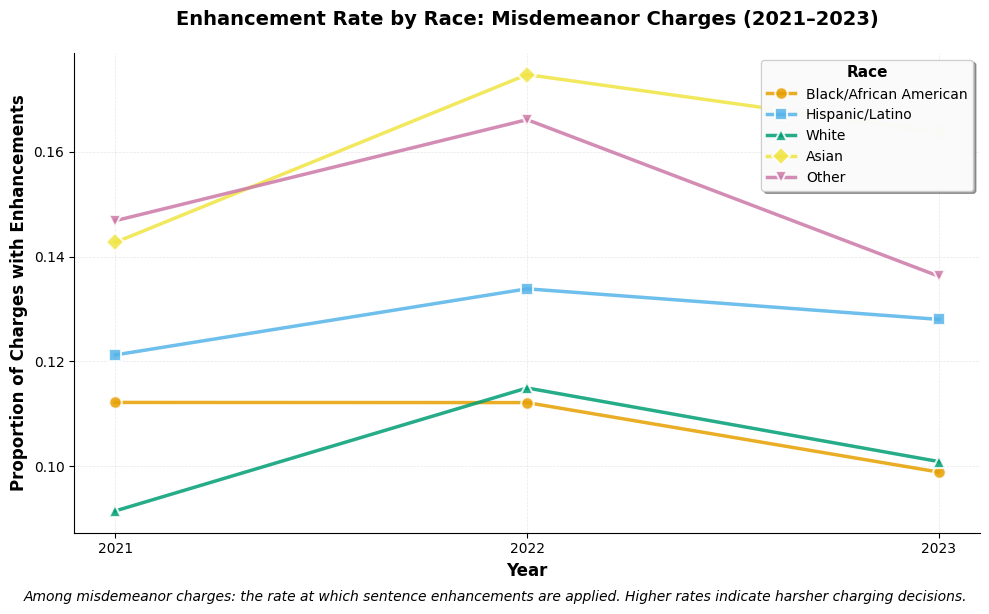

In [12]:
from utils_improved import visualize_policing, visualize_prosecution, create_disparity_comparison

visualize_policing(disc_vis)
visualize_prosecution(prosecution_analysis)

# Excluding Nondiscretionary Searches?

Currently in my analysis, I pull from all of the stops recorded in Orange County from 2019-2023, and then filter only for stops in which the reason for contact was discretionary (traffic violation or reasonable suspicion). Given that I want to identify racial disparities in policing and prosecution outcomes, I filtered for discretionary stops because I'm trying to measure disparities in officer discretion, thereby trying to identify discretionary racial disparities? So should I be more specific in my project title? AM I ASKING ABOUT DISCRETIONARY RACIAL DISPARITIES PERPETRATED BY CRIMINAL JUSTICE SYSTEM ACTORS?

Also, I've realized that stops also have discretionary and nondiscretionary bases for searches, which is relevant given that I'm measuring search rates, as well as hit rates based on stops involving searches. Given that I want to isolate discretionary racial disparities, I need to isolate officer discretion. Does that mean that I should calculate my search rates as the number of PURELY DISCRETIONARY searches (that is, searches with purely discretionary search bases) over the total number of stops with discretionary reasons for contact? And in turn, my hit rates should be the number of stops where contraband was recovered over the total number of stops with searches that were purely discretionary? What about mixed cases, which is 5% of all searches.

Right now, I'm only calculating discretionary disparity, but shouldn't I calculate exposure disparity too, to capture system-wide (and not necessarily actor-contributed) disparities?

Should I structure it as one analysis where I calculate stops per 1000, searches per 1000, overall search rate, and overall hit rate FOR THE ENTIRE STOP DATASET (includes non-discretionary stops) to identify all racial disparities, not just possibly due to officer discretion? And another analysis where I restrict to discretionary stop reasons and discretionary search bases, and then get the corresponding search rates and hit rates. And then compare the two to see if disparities exist overall, when officers have discretion, do disparities persist? If they do, suggests that disparities in discretionary decision-making.

In [ ]:
# Check how many stops conduct searches but with no recorded reason

# Condition: search occurred but search_type says "No search basis"
mask = (policing["action_any_search"]) & (policing["search_type"] == "No search basis")

# Number of such rows
num_problem = mask.sum()

# Total rows (or you can restrict denominator — see below)
total_rows = len(policing)

percent_problem = num_problem / total_rows

print("Count:", num_problem)
print(f"Percent of all rows: {percent_problem:.2%}")

# So negligible number of searches with no search basis recorded

Count: 210
Percent of all rows: 0.04%


In [ ]:
# Check how many stops have more than one search basis

search_basis_cols = [
    "search_basis_plain_view",
    "search_basis_plain_smell",
    "search_basis_consent",
    "search_basis_safety",
    "search_basis_suspect_weapon",
    "search_basis_evidence_of_crime",
    "search_basis_school_policy",
    "search_basis_emergency",
    "search_basis_canine",
    "search_basis_warrant",
    "search_basis_probation",
    "search_basis_incident_to_arrest",
    "search_basis_vehicle_inventory"
]

policing["num_search_bases"] = policing[search_basis_cols].sum(axis=1)
num_multi_basis = (policing["num_search_bases"] > 1).sum()
print("Number of stops with >1 search basis:", num_multi_basis)

percent_multi = (policing["num_search_bases"] > 1).mean()
print(f"Only {percent_multi:.2%} of stops have multiple search bases")

Number of stops with >1 search basis: 34829
Only 6.30% of stops have multiple search bases


# Policing Analysis: Stratification
See Databot

# Deeper Prosecution Analysis: Control by Charge
See Databot
- Look into why certain groups have higher rates than others – control by types of charges, starting with the most common and grouping the less common ones
- Look at the severity of charges for each group, e.g. 1st, 2nd, 3rd degree
- When get down to individual charges, get standard errors on everything – size points points by number of individuals in that bucket, then add in faint error bars to visualizations